In [18]:
!pip install scikit-learn plotly --quiet

import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge, Lasso
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1) Generăm datele și coeficienții adevărați
X, y, true_coefs = make_regression(
    n_samples=100, n_features=10, noise=15, coef=True, random_state=42
)
features = list(range(X.shape[1]))

# 2) Definim gama de α și calculăm coeficienții pentru fiecare model
alphas = np.logspace(-3, 2, 50)  # 50 de pași de la 0.001 la 100
ridge_coefs = []
lasso_coefs = []
for a in alphas:
    ridge_coefs.append(Ridge(alpha=a).fit(X, y).coef_)
    lasso_coefs.append(Lasso(alpha=a, max_iter=5000).fit(X, y).coef_)

# 3) Construim figura cu 3 subplots și trace-uri inițiale
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=["True Coefs", "Ridge Coefs", "Lasso Coefs"]
)
# true
fig.add_trace(go.Bar(x=features, y=true_coefs, marker_color='green'), row=1, col=1)
# ridge (initial)
fig.add_trace(go.Bar(x=features, y=ridge_coefs[0], marker_color='blue'), row=1, col=2)
# lasso (initial)
fig.add_trace(go.Bar(x=features, y=lasso_coefs[0], marker_color='red'), row=1, col=3)

# 4) Creăm frame-uri pentru fiecare α
frames = []
for i, a in enumerate(alphas):
    frames.append(go.Frame(
        data=[
            go.Bar(x=features, y=true_coefs, marker_color='green'),
            go.Bar(x=features, y=ridge_coefs[i], marker_color='blue'),
            go.Bar(x=features, y=lasso_coefs[i], marker_color='red'),
        ],
        name=f"{a:.4f}"
    ))
fig.frames = frames

# 5) Adăugăm sliderul
slider_steps = [
    {
        "method": "animate",
        "label": frame.name,
        "args": [
            [frame.name],
            {
                "mode": "immediate",
                "frame": {"duration": 0, "redraw": True},
                "transition": {"duration": 0}
            }
        ]
    }
    for frame in frames
]
fig.update_layout(
    sliders=[{
        "active": 0,
        "currentvalue": {"prefix": "α = "},
        "pad": {"t": 50},
        "steps": slider_steps
    }]
)

# 6) Afisăm
fig.update_layout(height=400, width=900, showlegend=False)
fig.show()


# 🌸 Logistic Regression (Breast Cancer)

CSV public cu date despre cancerul de sân
> Public CSV (raw): `https://raw.githubusercontent.com/pkmklong/Breast-Cancer-Wisconsin-Diagnostic-DataSet/master/data.csv`

---

In [2]:
# 1) Importuri
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, log_loss, confusion_matrix, roc_curve, auc
)

# Setări de afișare
pd.set_option("display.max_columns", 100)


## 1) Încărcare CSV și EDA scurt

In [3]:
# Link CSV public (raw)
url = "https://raw.githubusercontent.com/pkmklong/Breast-Cancer-Wisconsin-Diagnostic-DataSet/master/data.csv"

df = pd.read_csv(url)
print("Dimensiune:", df.shape)
df.head()

Dimensiune: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
# Coloane + valori lipsă + distribuția etichetei
print("Coloane:", list(df.columns))
print("\nValori lipsă pe coloană:\n", df.isna().sum())

print("\nDistribuție etichetă (diagnosis):\n", df["diagnosis"].value_counts())


Coloane: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Valori lipsă pe coloană:
 id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se   

Modelul de LogisticRegression din scikit-learn știe nativ să lucreze cu această formă pentru clasificare binară, deci **nu e nevoie de one-hot encoding.**

In [5]:
# Convertim eticheta: M=1 (malign), B=0 (benign)
df = df.copy()
df["target"] = df["diagnosis"].map({"M": 1, "B": 0}).astype(int)
print(df[["diagnosis", "target"]].head())


  diagnosis  target
0         M       1
1         M       1
2         M       1
3         M       1
4         M       1


### Alegem două trăsături ușor de vizualizat
Pentru simplitate educațională, folosim doar `radius_mean` și `texture_mean` pentru plot‑uri 2D.


In [6]:
# Verificăm că features există
for col in ["radius_mean", "texture_mean"]:
    if col not in df.columns:
        raise ValueError(f"Coloana necesară '{col}' lipsește din dataset.")

features = ["radius_mean", "texture_mean"]
X = df[features].values
y = df["target"].values


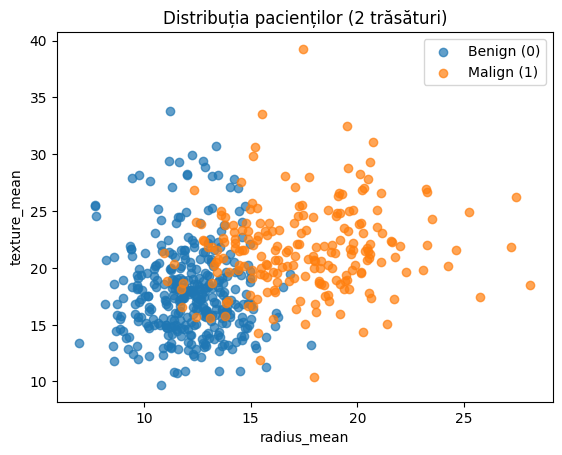

In [7]:
# Scatter simplu (doar matplotlib, fără seaborn)
plt.figure()
mask_m = (y == 1)
mask_b = (y == 0)
plt.scatter(X[mask_b, 0], X[mask_b, 1], label="Benign (0)", alpha=0.7)
plt.scatter(X[mask_m, 0], X[mask_m, 1], label="Malign (1)", alpha=0.7)
plt.xlabel("radius_mean")
plt.ylabel("texture_mean")
plt.title("Distribuția pacienților (2 trăsături)")
plt.legend()
plt.show()


## 2) Split train/test + standardizare

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dimensiuni:")
print("X_train:", X_train_scaled.shape, "X_test:", X_test_scaled.shape)


Dimensiuni:
X_train: (455, 2) X_test: (114, 2)


## 3) Model: Logistic Regression

In [9]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Acuratețe (train):", accuracy_score(y_train, model.predict(X_train_scaled)))
print("Acuratețe (test): ", accuracy_score(y_test, y_pred))
print("Log Loss (test): ", log_loss(y_test, y_proba))

print("\nIntercept:", model.intercept_)
print("Coeficienți (pentru features în ordinea {}):".format(features), model.coef_)


Acuratețe (train): 0.8945054945054945
Acuratețe (test):  0.868421052631579
Log Loss (test):  0.2580216390081843

Intercept: [-0.69039273]
Coeficienți (pentru features în ordinea ['radius_mean', 'texture_mean']): [[3.25713351 0.86797885]]


## 4) Log Loss — exemplu pe un singur punct și curbe de pierdere

In [10]:
# Exemplu: un caz adevărat (y=1) cu două predicții probabilistice
y_true = 1

p_good = 0.9
loss_good = - (y_true*np.log(p_good) + (1-y_true)*np.log(1-p_good))

p_bad = 0.1
loss_bad = - (y_true*np.log(p_bad) + (1-y_true)*np.log(1-p_bad))

print(f"Log Loss (y=1, p=0.9): {loss_good:.4f}  -> predicție bună, pierdere mică")
print(f"Log Loss (y=1, p=0.1): {loss_bad:.4f}  -> predicție slabă, pierdere mare")


Log Loss (y=1, p=0.9): 0.1054  -> predicție bună, pierdere mică
Log Loss (y=1, p=0.1): 2.3026  -> predicție slabă, pierdere mare


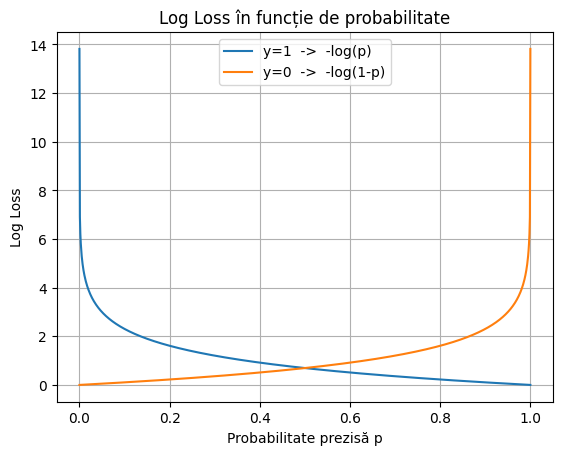

In [11]:
# Curbe log-loss pentru y=1 și y=0, în funcție de p în [1e-6, 1-1e-6]
p = np.linspace(1e-6, 1-1e-6, 1000)
loss_y1 = -np.log(p)           # y=1
loss_y0 = -np.log(1 - p)       # y=0

plt.figure()
plt.plot(p, loss_y1, label="y=1  ->  -log(p)")
plt.plot(p, loss_y0, label="y=0  ->  -log(1-p)")
plt.xlabel("Probabilitate prezisă p")
plt.ylabel("Log Loss")
plt.title("Log Loss în funcție de probabilitate")
plt.legend()
plt.grid(True)
plt.show()


## 5) Plot‑uri explicative

### 5.1 Funcția Sigmoid

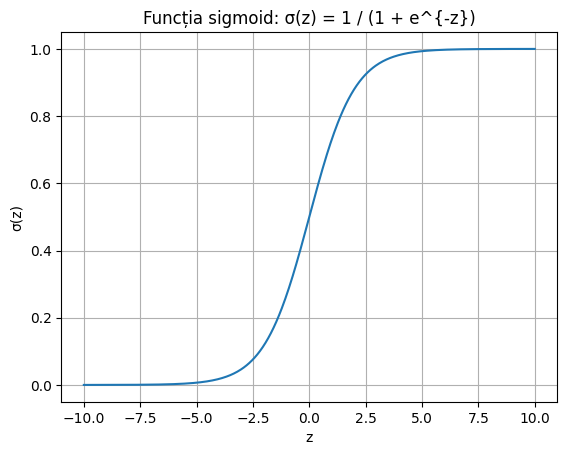

In [12]:
z = np.linspace(-10, 10, 500)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure()
plt.plot(z, sigmoid)
plt.title("Funcția sigmoid: σ(z) = 1 / (1 + e^{-z})")
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.grid(True)
plt.show()


### 5.2 Frontiera de decizie (2D)

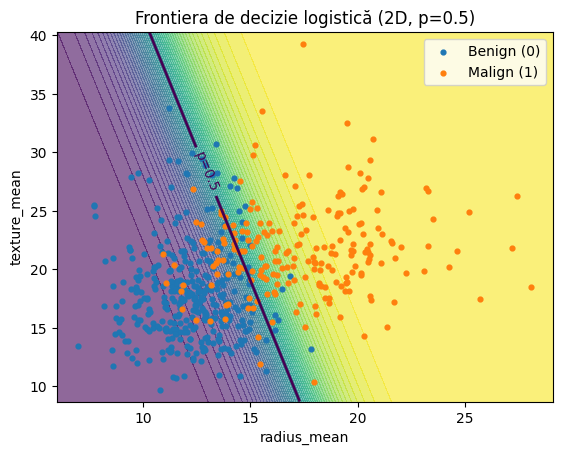

In [13]:
# Construim o grilă 2D în spațiul celor două trăsături
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)  # important: folosim același scaler
proba_grid = model.predict_proba(grid_scaled)[:, 1].reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, proba_grid, levels=50, alpha=0.6)
# setăm și linia p=0.5 (frontiera de decizie)
cs = plt.contour(xx, yy, proba_grid, levels=[0.5], linewidths=2)
plt.clabel(cs, inline=True, fontsize=10, fmt={0.5: "p=0.5"})

# punctele reale
plt.scatter(X[mask_b, 0], X[mask_b, 1], s=12, label="Benign (0)")
plt.scatter(X[mask_m, 0], X[mask_m, 1], s=12, label="Malign (1)")
plt.xlabel("radius_mean")
plt.ylabel("texture_mean")
plt.title("Frontiera de decizie logistică (2D, p=0.5)")
plt.legend()
plt.show()


### 5.3 Confusion Matrix

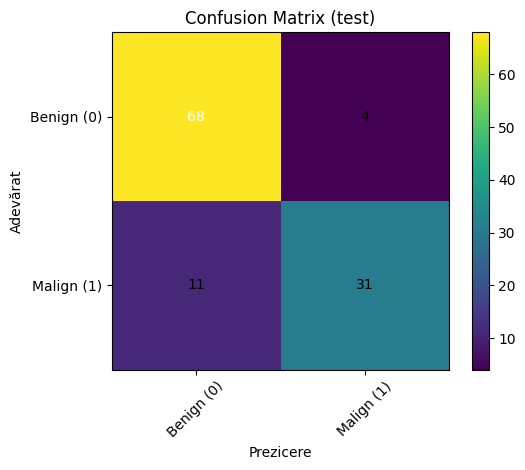

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
im = plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (test)")
plt.colorbar(im, fraction=0.046, pad=0.04)
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Benign (0)", "Malign (1)"], rotation=45)
plt.yticks(tick_marks, ["Benign (0)", "Malign (1)"])

# Anotări pe pătrate
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.ylabel("Adevărat")
plt.xlabel("Prezicere")
plt.tight_layout()
plt.show()


## 6) Interpretare rapidă a coeficienților

In [15]:
coefs = pd.DataFrame({
    "feature": features,
    "coef": model.coef_.ravel()
}).sort_values("coef", ascending=False)
coefs


,feature,coef
0,radius_mean,3.257134
1,texture_mean,0.867979


In [16]:
# Experiment: efectul cutoff-ului
cutoff = 0.8  # încercați valori: 0.3, 0.6 etc.
y_pred_cut = (y_proba >= cutoff).astype(int)

print(f"Acuratețe (cutoff={cutoff}):", accuracy_score(y_test, y_pred_cut))
cm_cut = confusion_matrix(y_test, y_pred_cut)
cm_cut


Acuratețe (cutoff=0.8): 0.8421052631578947


array([[72,  0],
       [18, 24]])

In [17]:
# Vizualizare diferență între predict_proba și predict
import pandas as pd
import matplotlib.pyplot as plt

# Alegem câteva exemple din test
n = 20
examples = pd.DataFrame({
    "Prob_malign (predict_proba)": y_proba[:n],
    "Etichetă_reală": y_test[:n],
    "Predicție_finală (predict)": y_pred[:n]
})

display(examples)

,Prob_malign (predict_proba),Etichetă_reală,Predicție_finală (predict)
0,0.007086,0,0
1,0.998203,1,1
2,0.612376,0,1
3,0.404269,1,0
4,0.707314,0,1
5,0.004221,0,0
6,0.262803,1,0
7,0.266058,0,0
8,0.012613,0,0
9,0.057369,0,0



### 🧪 Idei
- Schimbați perechea de trăsături (ex: `radius_mean` & `perimeter_mean`) și re‑rulați.
- Folosiți **mai multe trăsături** (încercați toate `*_mean`) și comparați scorurile.
- Ce înseamnă coeficienții pozitivi și negativi din model?
- Cum se schimbă performanța când adăugăm mai multe features?
- Ce se întâmplă când reducem dimensiunea setului de antrenare?
- Dacă majoritatea valorilor sunt în jur de 0.5, ce înseamnă?
- Dacă funcția sigmoid este foarte abruptă, ce înseamnă pentru exemplul nostru?

